In [1]:
import pandapower as pp
import numpy as np
import xlsxwriter as xl
import pandapower.plotting as pplt
import matplotlib.pyplot as plt
import pandapower.plotting.plotly as pplot
import plotly.graph_objs as go
import pandas as pd
import os
import tempfile
from pandapower.timeseries import DFData
from pandapower.timeseries import OutputWriter
from pandapower.timeseries.run_time_series import run_timeseries
from pandapower.control import ConstControl
from pandapower.plotting import simple_plot


In [2]:
#create empty net
net = pp.create_empty_network()

In [3]:
#importing data from Excel
bus_data = pd.read_excel('network.xlsx', sheet_name= 'bus_list')
line_data = pd.read_excel('network.xlsx', sheet_name= 'line_list')
switch_data = pd.read_excel('network.xlsx', sheet_name= 'switch_list')
trafo_data = pd.read_excel('network.xlsx', sheet_name= 'trafo_list')
load_data = pd.read_excel('network.xlsx', sheet_name= 'load_list')

In [4]:
# Validate bus data
required_bus_columns = ['Name', 'Voltage_kV']
if not all(col in bus_data.columns for col in required_bus_columns):
    raise ValueError(f"Bus data must contain the columns: {required_bus_columns}")

#buses
for _, b in bus_data.iterrows(): 
    pp.create_bus(net, name=b.Name, vn_kv=b.Voltage_kV)

In [5]:
# Validate line data
required_line_columns = ['Name', 'From', 'To', 'Length_kms', 'r_ohm_per_km', 'x_ohm_per_km', 'c_nf_per_km', 'max_i_ka', 'parallel', 'Diameter']
if not all(col in line_data.columns for col in required_line_columns):
    raise ValueError(f"Line data must contain the columns: {required_line_columns}")

# lines
for _, linerow in line_data.iterrows():
    TB = linerow['To']
    FB = linerow['From']
    lin_name = linerow['Name']
    lin_dia = linerow['Diameter']
    lin_resistance = linerow['r_ohm_per_km']
    lin_reactance = linerow['x_ohm_per_km']
    lin_capacitance = linerow['c_nf_per_km']
    lin_max_current = linerow['max_i_ka']

    A = pp.get_element_index(net, "bus", FB)
    B = pp.get_element_index(net, "bus", TB)
    C = linerow['Length_kms']
    D = linerow['parallel']
    pp.create_line_from_parameters(
        net,
        from_bus=A,
        to_bus=B,
        length_km=C,
        name=lin_name,
        r_ohm_per_km=lin_resistance,
        x_ohm_per_km=lin_reactance,
        c_nf_per_km=lin_capacitance,
        max_i_ka=lin_max_current,
        parallel=D,
        diameter=lin_dia,
    )

In [6]:
# Validate switch data
required_switch_columns = ['bus', 'Line', 'state']
if not all(col in switch_data.columns for col in required_switch_columns):
    raise ValueError(f"Switch data must contain the columns: {required_switch_columns}")

#Switch
for lidx, linerow in switch_data.iterrows():
    A=pp.get_element_index(net, "bus", switch_data.bus[lidx])
    B=pp.get_element_index(net, "line", switch_data.Line[lidx])
    pp.create_switch(net, bus=A, element=B, et="l", closed=switch_data.state[lidx])

In [7]:
# Validate trafo data
required_trafo_columns = ['Name', 'From', 'To', 'app_p']
if not all(col in trafo_data.columns for col in required_trafo_columns):
    raise ValueError(f"Trafo data must contain the columns: {required_trafo_columns}")


#Trafo
for lidx, linerow in trafo_data.iterrows():
    TB=trafo_data.To[lidx]
    FB=trafo_data.From[lidx]
    A=pp.get_element_index(net,"bus",FB)
    B=pp.get_element_index(net,"bus",TB)
    C=trafo_data.app_p[lidx]
    pp.create_transformer_from_parameters(net, hv_bus=A, lv_bus=B, sn_mva=C, vn_hv_kv= trafo_data.hv_vol[lidx], vn_lv_kv=trafo_data.lv_vol[lidx],
                                                vk_percent= trafo_data.vk_percent[lidx], vkr_percent= trafo_data.vkr_percent[lidx], pfe_kw= trafo_data.pfe_kw[lidx], i0_percent= trafo_data.i0_percent[lidx],name=trafo_data.Name[lidx])


In [8]:
# Create external grid
try:
    EG = pp.get_element_index(net, "bus", "EG")
    pp.create_ext_grid(net, bus=EG, vm_pu =1.02, name="ALVARSBERG")
except KeyError:
    print("Warning: External Grid bus 'EG' not found. Ensure 'EG' bus is defined in bus_list sheet.")

In [9]:
# Validate load data
required_load_columns = ['Node', 'Name']
if not all(col in load_data.columns for col in required_load_columns):
    raise ValueError(f"Load data must contain the columns: {required_load_columns}")

#load
for lidx, linerow in load_data.iterrows():
    A=pp.get_element_index(net, "bus", load_data.Node[lidx])
    pp.create_load(net, bus=A, p_mw=0, q_mvar=0, name=load_data.Name[lidx])

In [10]:
# Manually disable known disconnected islands
net.line.loc[[7, 8, 19], "in_service"] = False
net.trafo.loc[[8] + list(range(9, 20)) + [28], "in_service"] = False

# Disable ALL loads on the disconnected buses (more robust than hardcoding load indices)
disc_buses = [16, 17, 36, 37, 42, 43]
net.load.loc[net.load.bus.isin(disc_buses), "in_service"] = False

In [11]:
import pandapower.plotting.plotly as pplot
from pandapower.plotting.generic_geodata import create_generic_coordinates

# Create coordinates only if missing
if net.bus.geo.isna().all() and net.line.geo.isna().all():
    create_generic_coordinates(net)

fig = pplot.simple_plotly(
    net,
    respect_switches=True,
    auto_open=False
)

# Better layout (prevents trimmed title and cramped legend)
fig.update_layout(
    title=dict(
        text="Interactive Network",
        x=0.5,            # center title
        xanchor="center",
        y=0.98,
        yanchor="top"
    ),
    width=1100,
    height=800,
    margin=dict(l=40, r=260, t=90, b=40),  # extra top/right space
    legend=dict(
        x=1.02, y=1.0,    # put legend outside plot area
        xanchor="left",
        yanchor="top",
        bgcolor="rgba(255,255,255,0.85)"
    ),
    hovermode="closest"
)

# Keep equal scaling so network shape is not distorted
fig.update_xaxes(scaleanchor="y", scaleratio=1, showgrid=False, zeroline=False)
fig.update_yaxes(showgrid=False, zeroline=False)

fig.show()

In [12]:
profilesA = pd.read_excel('optimized/optimized_Pmw_15min.xlsx')
profilesR = pd.read_excel('optimized/optimized_Qmvar_15min.xlsx')
DSA = DFData(profilesA)
DSR = DFData(profilesR)

def create_controllers(net, DSA, DSR, profilesA, profilesR):
    for load_idx in net.load.index[net.load.in_service]:
        element_index = [load_idx]
        profilesA_name = list(profilesA)[load_idx]
        profilesR_name = list(profilesR)[load_idx]
        ConstControl(net, element='load', variable='p_mw', element_index=element_index, data_source=DSA, profile_name=profilesA_name)
        ConstControl(net, element='load', variable='q_mvar', element_index=element_index, data_source=DSR, profile_name=profilesR_name)
        
def create_output_writer(net, time_steps, output_dir):
    ow = OutputWriter(net, time_steps, output_path=output_dir, output_file_type='.xlsx', log_variables=list())
    #these variables are saved to the harddisk after / during the time series loop
    ow.log_variable('res_load', 'p_mw')
    ow.log_variable('res_bus', 'vm_pu')
    ow.log_variable('res_line', 'loading_percent')
    ow.log_variable('res_line','p_from_mw')
    ow.log_variable('res_line','p_to_mw')
    ow.log_variable('res_line', 'i_ka')
    ow.log_variable('res_trafo', 'loading_percent')
    return ow


def timeseries(output_dir, DSA, DSR, profilesA, profilesR):
    n_timesteps = 35040
    create_controllers(net, DSA, DSR, profilesA, profilesR)
    time_steps = range(0, n_timesteps)
    ow = create_output_writer(net, time_steps, output_dir)
    try:
        pp.timeseries.run_timeseries(net, time_steps)
    except pp.LoadflowNotConverged:
        print("Loadflow did not converge")
        # Add additional diagnostics or debugging information here if needed

In [13]:
output_dir = "optimized/outputs/simulation_results"
if not os.path.exists(output_dir):
    os.mkdir(output_dir)
timeseries(output_dir, DSA, DSR, profilesA, profilesR)
  
pp.diagnostic(net, report_style='compact', warnings_only=False, return_result_dict=True, overload_scaling_factor=0.001, min_r_ohm=0.001, min_x_ohm=0.001, min_r_pu=1e-05, min_x_pu=1e-05, nom_voltage_tolerance=0.3, numba_tolerance=1e-05)

100%|██████████| 35040/35040 [03:43<00:00, 157.03it/s]


_____________ PANDAPOWER DIAGNOSTIC TOOL _____________ 


 --------

disconnected_elements:

disonnected_section: {'buses': [36]}
disonnected_section: {'buses': [37]}
disonnected_section: {'buses': [42]}
disonnected_section: {'buses': [43]}
disonnected_section: {'buses': [16]}
disonnected_section: {'buses': [17]}

 --------


 --------


 --------


 --------


 --------


 --------


 --------


 --------


 --------


 --------


 --------


 --------


 --------

_____________ END OF PANDAPOWER DIAGNOSTIC _____________ 


{'disconnected_elements': [{'buses': [36]},
  {'buses': [37]},
  {'buses': [42]},
  {'buses': [43]},
  {'buses': [16]},
  {'buses': [17]}]}

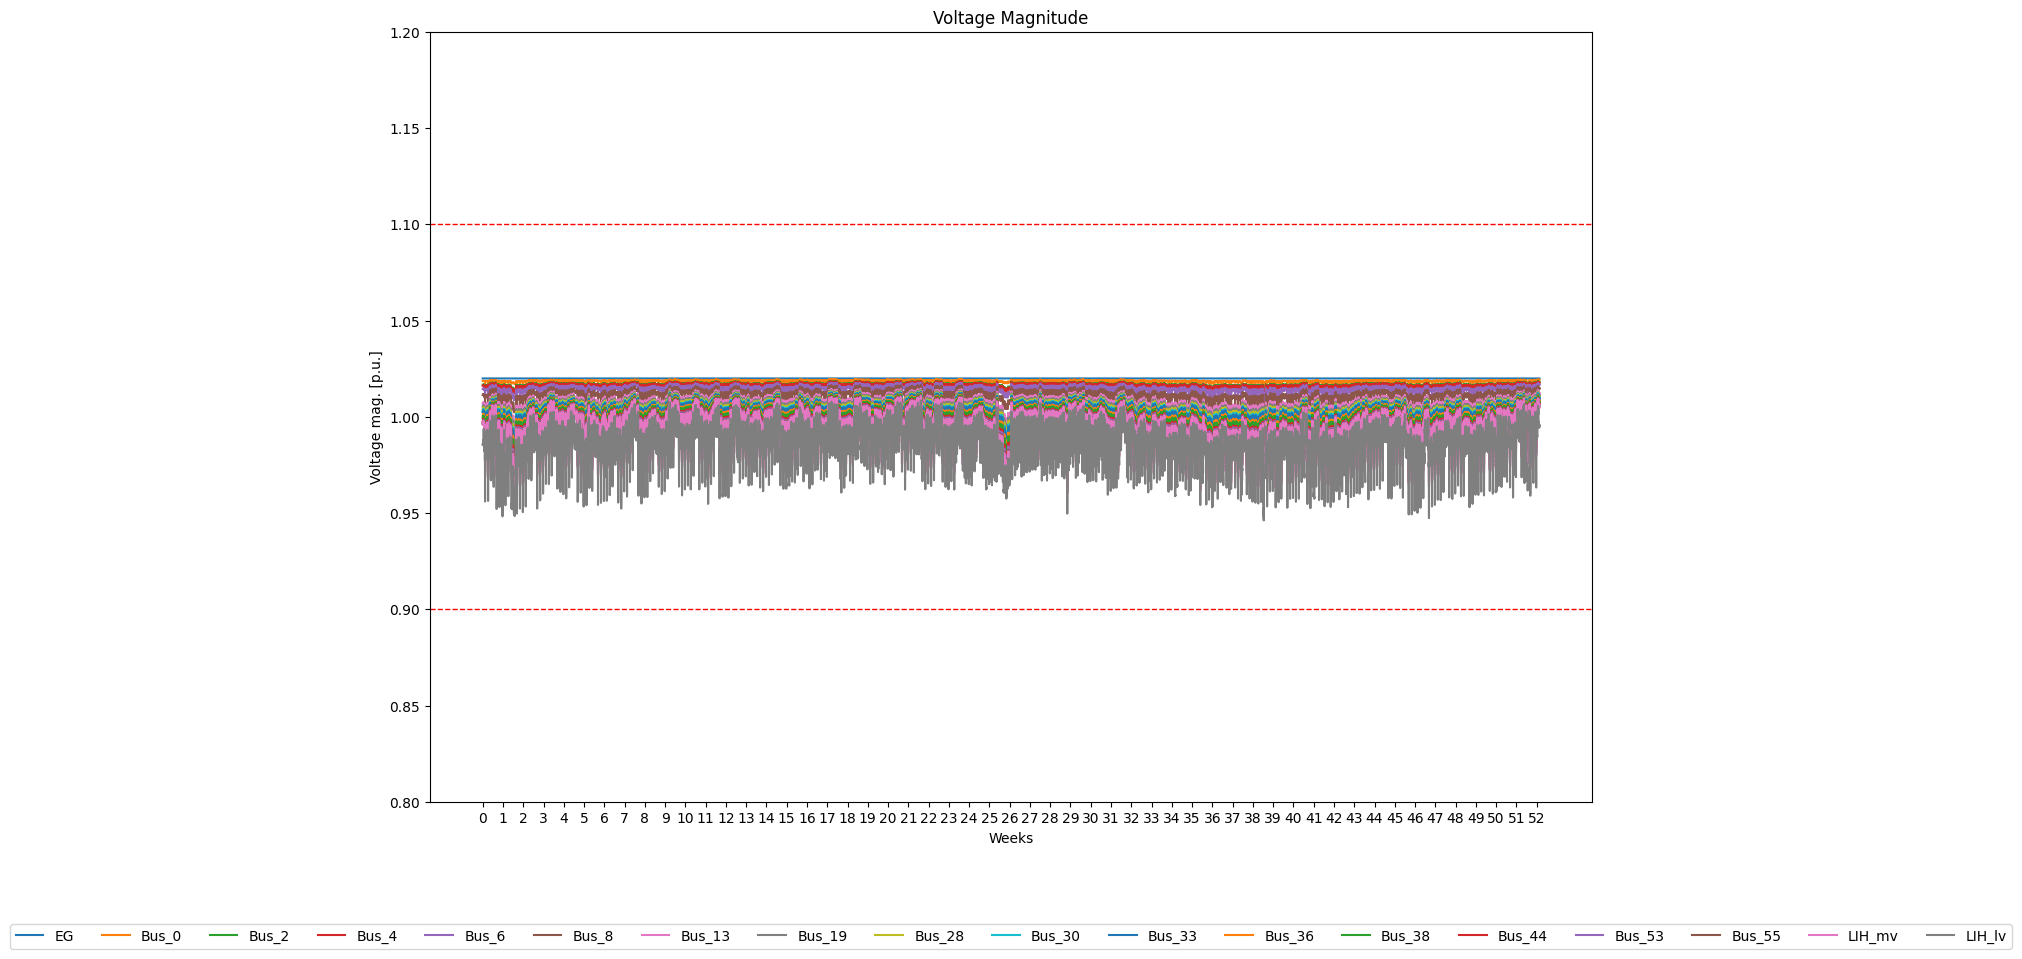

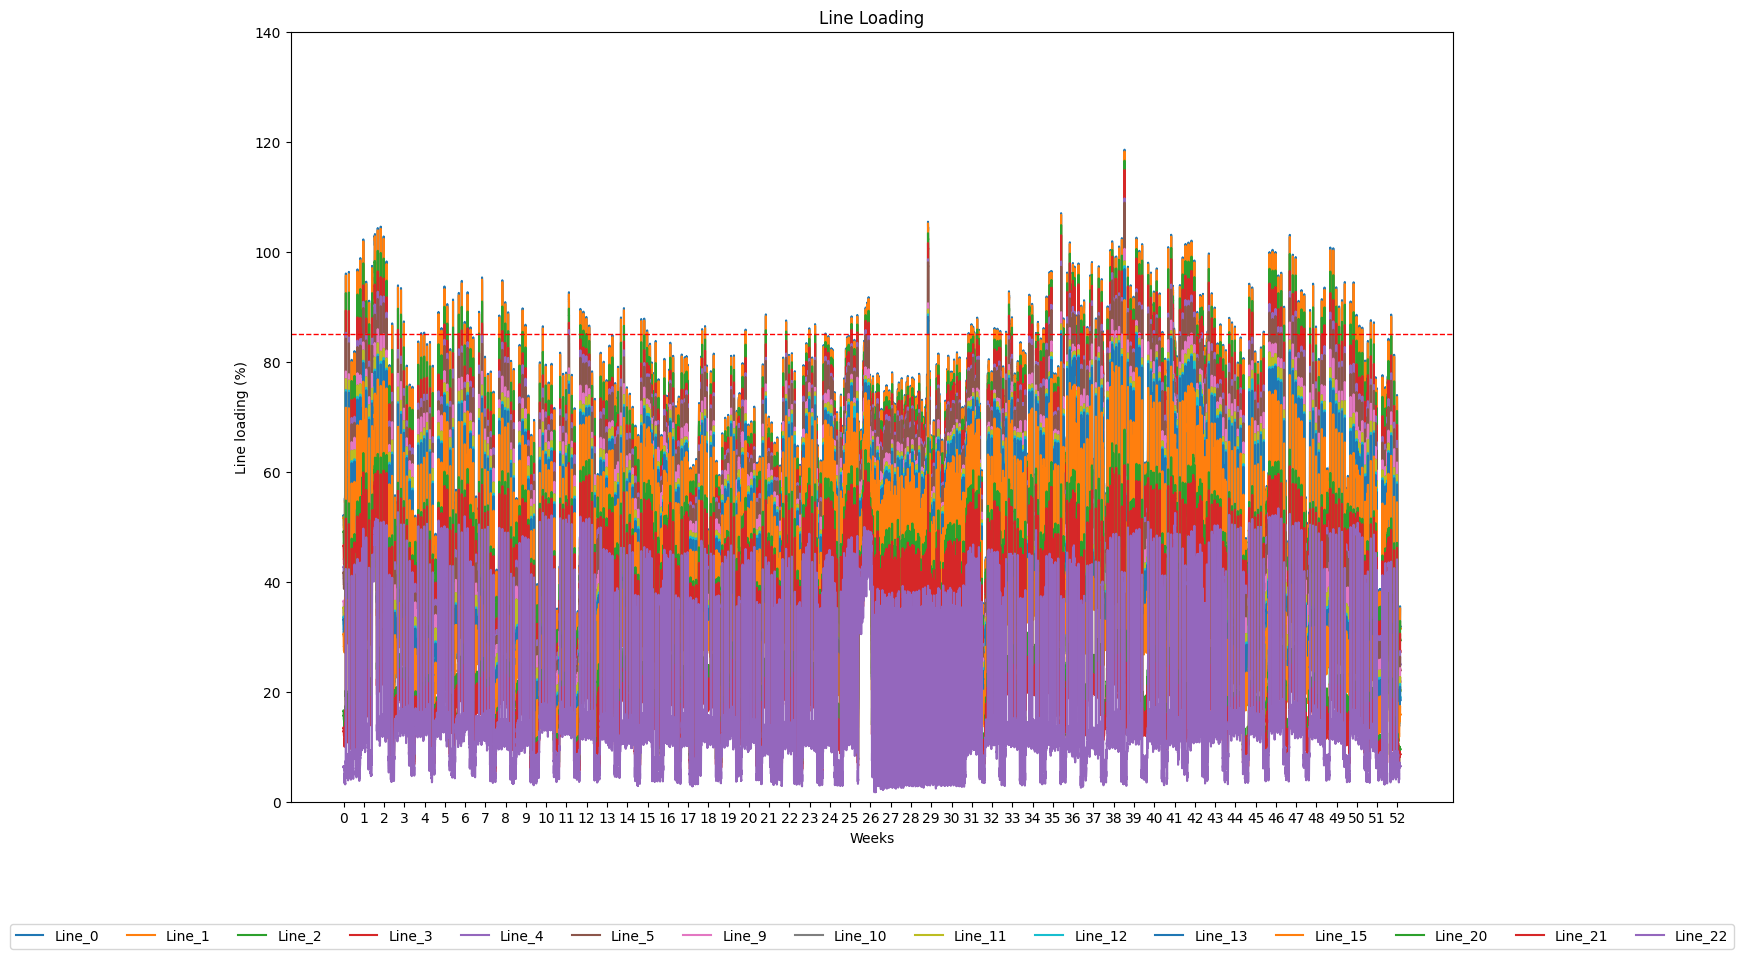

In [14]:
# Read the files
# Voltage magnitude
vm_pu_file = os.path.join(output_dir, "res_bus", "vm_pu.xlsx")
vm_pu = pd.read_excel(vm_pu_file, index_col=0)

# Line loading results
ll_file = os.path.join(output_dir, "res_line", "loading_percent.xlsx")
line_loading = pd.read_excel(ll_file, index_col=0)

# Trafo loading results
tl_file = os.path.join(output_dir, "res_trafo", "loading_percent.xlsx")
trafo_loading = pd.read_excel(tl_file, index_col=0)

# Helper function to convert timesteps to weeks
def timesteps_to_weeks(timesteps):
    return timesteps / 672

def week_axis_ticks(n_timesteps):
    ticks = list(range(0, n_timesteps, 672))
    return ticks, list(range(len(ticks)))

# Network Voltage magnitude
column_indices_to_plot = [0, 1, 2, 4, 6, 8, 10, 12, 18, 20, 21, 23, 25, 29, 38, 40, 44, 45]
legend_labels = ["EG", "Bus_0", "Bus_2", "Bus_4", "Bus_6", "Bus_8", "Bus_13", 
                "Bus_19", "Bus_28", "Bus_30", 
                 "Bus_33", "Bus_36", "Bus_38", "Bus_44", "Bus_53", "Bus_55", "LIH_mv", "LIH_lv"]
fig, ax = plt.subplots(figsize=(15, 10))
for i, column_index in enumerate(column_indices_to_plot):
    legend_label = legend_labels[i]
    vm_pu.iloc[:, column_index].plot(label=legend_label)
plt.axhline(y=0.9, color='red', linestyle='--', linewidth=1)
plt.axhline(y=1.1, color='red', linestyle='--', linewidth=1)
plt.xlabel("Weeks")
plt.ylabel("Voltage mag. [p.u.]")
plt.title("Voltage Magnitude")
plt.ylim(0.8, 1.2)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(column_indices_to_plot))
week_ticks, week_labels = week_axis_ticks(vm_pu.shape[0])
plt.xticks(ticks=week_ticks, labels=week_labels)
plt.grid(False)  # Remove gridlines
plt.show()

# Line loading 
column_indices_to_plot = [0, 1, 2, 3, 4, 5, 9, 10, 11, 12, 13, 15, 20, 21, 22]
legend_labels = [
    'Line_0', 'Line_1', 'Line_2', 'Line_3', 'Line_4', 'Line_5',
    'Line_9', 'Line_10', 'Line_11', 'Line_12', 'Line_13', 'Line_15',
    'Line_20', 'Line_21', 'Line_22',
]
fig, ax = plt.subplots(figsize=(15, 10))
for i, column_index in enumerate(column_indices_to_plot):
    legend_label = legend_labels[i]
    line_loading.iloc[:, column_index].plot(label=legend_label)
plt.axhline(y=85, color='red', linestyle='--', linewidth=1)
plt.xlabel("Weeks")
plt.ylabel("Line loading (%)")
plt.title("Line Loading")
plt.ylim(0, 140)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(column_indices_to_plot))
week_ticks, week_labels = week_axis_ticks(line_loading.shape[0])
plt.xticks(ticks=week_ticks, labels=week_labels)
plt.grid(False)  # Remove gridlines
plt.show()

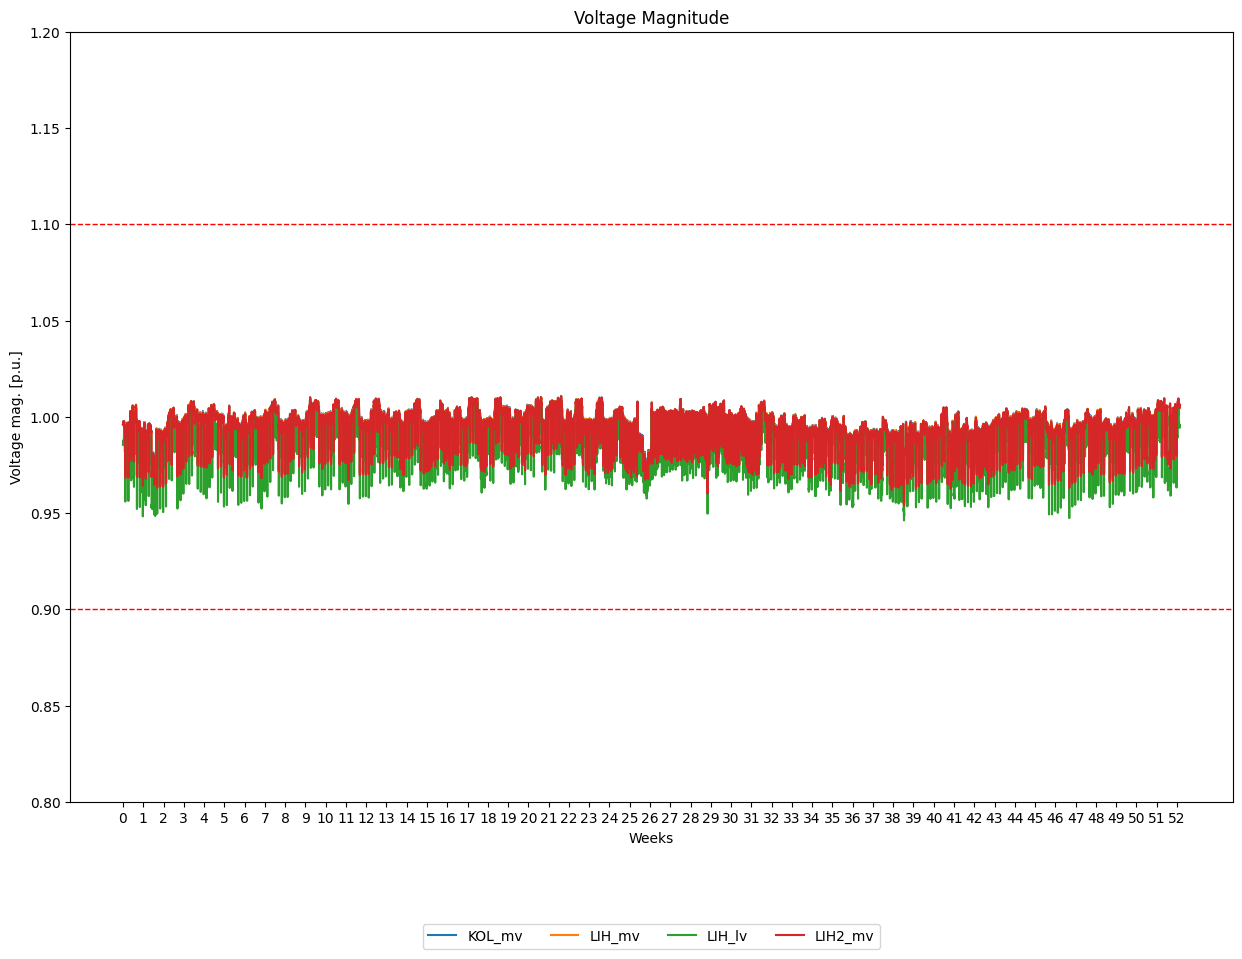

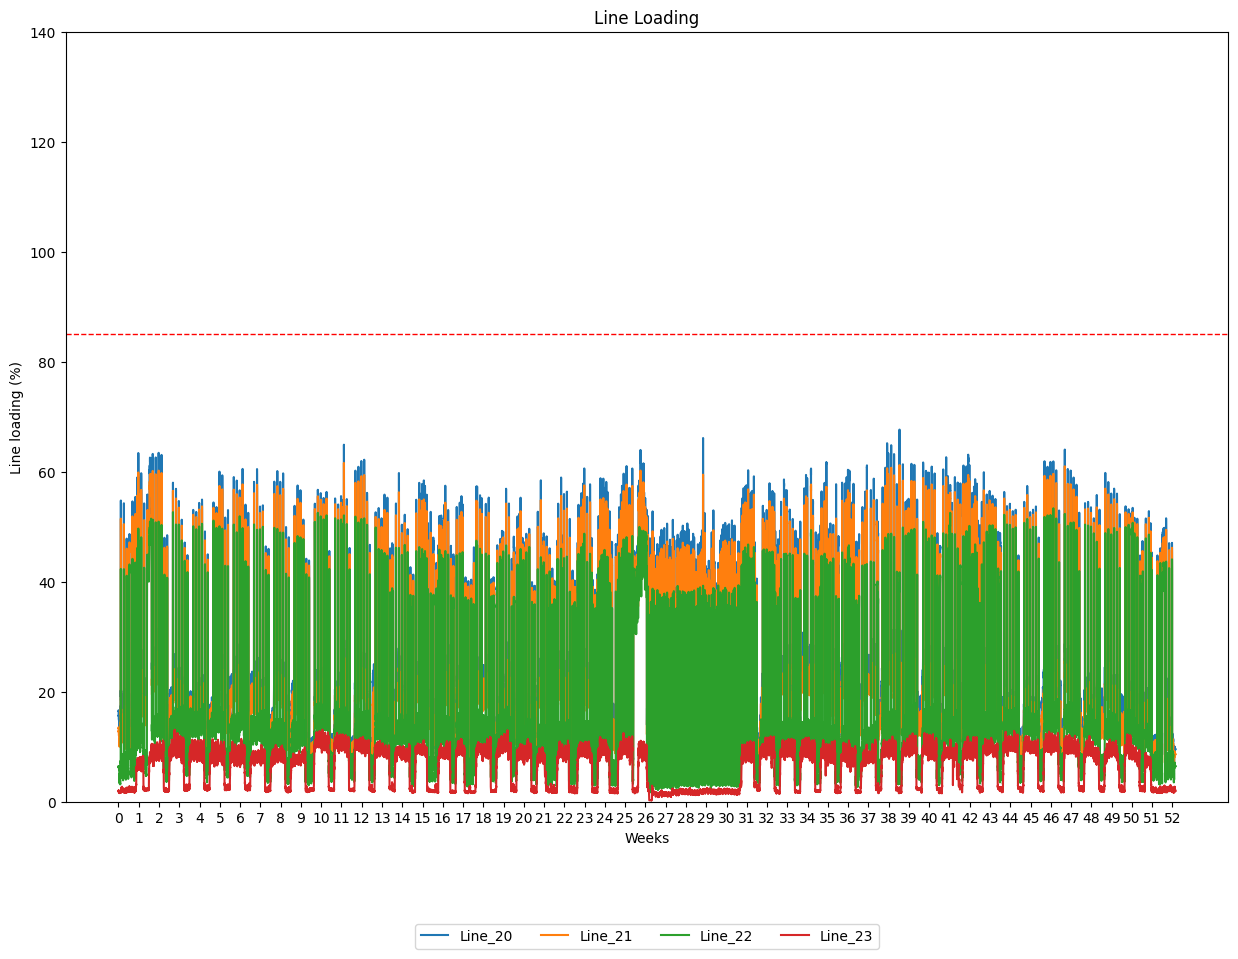

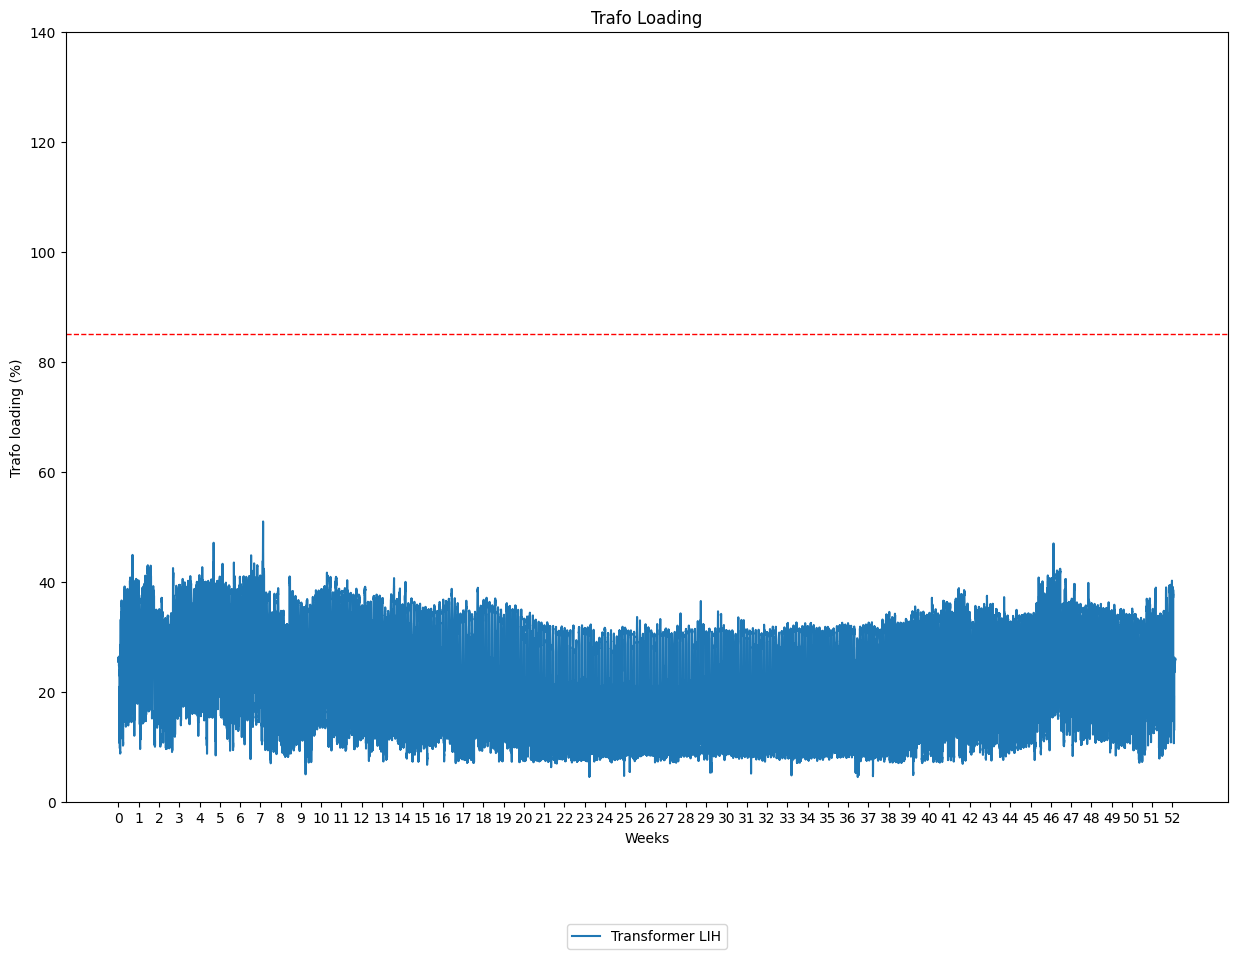

In [15]:
# Read the files
# Voltage magnitude
vm_pu_file = os.path.join(output_dir, "res_bus", "vm_pu.xlsx")
vm_pu = pd.read_excel(vm_pu_file, index_col=0)

# Line loading results
ll_file = os.path.join(output_dir, "res_line", "loading_percent.xlsx")
line_loading = pd.read_excel(ll_file, index_col=0)

# Trafo loading results
tl_file = os.path.join(output_dir, "res_trafo", "loading_percent.xlsx")
trafo_loading = pd.read_excel(tl_file, index_col=0)

# Helper function to convert timesteps to weeks
def timesteps_to_weeks(timesteps):
    return timesteps / 672

def week_axis_ticks(n_timesteps):
    ticks = list(range(0, n_timesteps, 672))
    return ticks, list(range(len(ticks)))


# Network Voltage magnitude (requested series)
column_indices_to_plot = [40, 44, 45, 46]
legend_labels = ['KOL_mv', 'LIH_mv', 'LIH_lv', 'LIH2_mv']

fig, ax = plt.subplots(figsize=(15, 10))
for i, column_index in enumerate(column_indices_to_plot):
    legend_label = legend_labels[i]
    vm_pu.iloc[:, column_index].plot(label=legend_label)

plt.axhline(y=0.9, color='red', linestyle='--', linewidth=1)
plt.axhline(y=1.1, color='red', linestyle='--', linewidth=1)
plt.xlabel("Weeks")
plt.ylabel("Voltage mag. [p.u.]")
plt.title("Voltage Magnitude")
plt.ylim(0.8, 1.2)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(column_indices_to_plot))
week_ticks, week_labels = week_axis_ticks(vm_pu.shape[0])
plt.xticks(ticks=week_ticks, labels=week_labels)
plt.grid(False)
plt.show()


# Line loading (requested series)
column_indices_to_plot = [20, 21, 22, 23]
legend_labels = ['Line_20', 'Line_21', 'Line_22', 'Line_23']

fig, ax = plt.subplots(figsize=(15, 10))
for i, column_index in enumerate(column_indices_to_plot):
    legend_label = legend_labels[i]
    line_loading.iloc[:, column_index].plot(label=legend_label)

plt.axhline(y=85, color='red', linestyle='--', linewidth=1)
plt.xlabel("Weeks")
plt.ylabel("Line loading (%)")
plt.title("Line Loading")
plt.ylim(0, 140)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(column_indices_to_plot))
week_ticks, week_labels = week_axis_ticks(line_loading.shape[0])
plt.xticks(ticks=week_ticks, labels=week_labels)
plt.grid(False)
plt.show()


# Trafo loading (Transformer LIH)
columns_to_plot = [31]   # int
legend_labels = ['Transformer LIH']

fig, ax = plt.subplots(figsize=(15, 10))
for i, col_name in enumerate(columns_to_plot):
    trafo_loading[col_name].plot(label=legend_labels[i])

plt.axhline(y=85, color='red', linestyle='--', linewidth=1)
plt.xlabel("Weeks")
plt.ylabel("Trafo loading (%)")
plt.title("Trafo Loading")
plt.ylim(0, 140)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(columns_to_plot))
week_ticks, week_labels = week_axis_ticks(trafo_loading.shape[0])
plt.xticks(ticks=week_ticks, labels=week_labels)
plt.grid(False)
plt.show()

In [16]:
import numpy as np
import pandas as pd

# If trafo_loading is not already loaded:
# tl_file = os.path.join(output_dir, "res_trafo", "loading_percent.xlsx")
# trafo_loading = pd.read_excel(tl_file, index_col=0)

N_YEAR_15MIN = 35040  # 365 days × 96 steps/day (15-min resolution)

trafo_idx = 31
trafo_name = "Transformer LIH"  # optional label

# trafo_loading columns are indexed by transformer index (same as columns_to_plot = [31])
s = trafo_loading[trafo_idx].to_numpy(dtype=float)
s = s[~np.isnan(s)]
n_valid = len(s)

m80 = s >= 80.0
m100 = s > 100.0

n_ge_80 = int(m80.sum())
n_gt_100 = int(m100.sum())

share_ge_80_pct = n_ge_80 / N_YEAR_15MIN * 100.0
share_gt_100_pct = n_gt_100 / N_YEAR_15MIN * 100.0

# Optional: share relative to valid (non-NaN) timesteps only
share_ge_80_of_valid_pct = n_ge_80 / n_valid * 100.0
share_gt_100_of_valid_pct = n_gt_100 / n_valid * 100.0

print(f"{trafo_name} (index {trafo_idx})")
print(f"  >= 80% loading: {n_ge_80:,} timesteps  ({share_ge_80_pct:.3f}% of year)")
print(f"  >  100% loading: {n_gt_100:,} timesteps  ({share_gt_100_pct:.3f}% of year)")
print(f"  Max loading: {np.max(s):.2f}%")

Transformer LIH (index 31)
  >= 80% loading: 0 timesteps  (0.000% of year)
  >  100% loading: 0 timesteps  (0.000% of year)
  Max loading: 51.00%


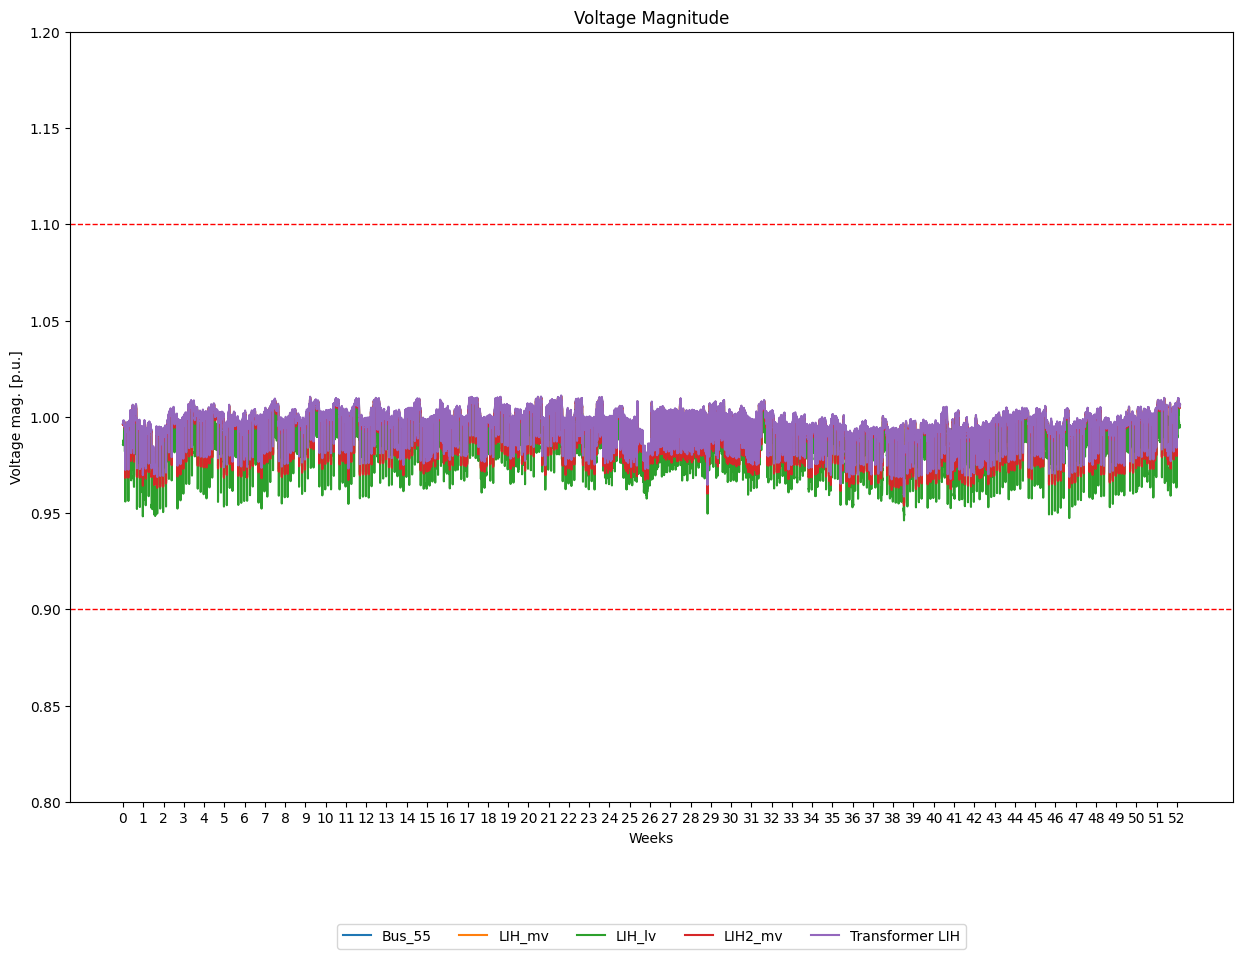

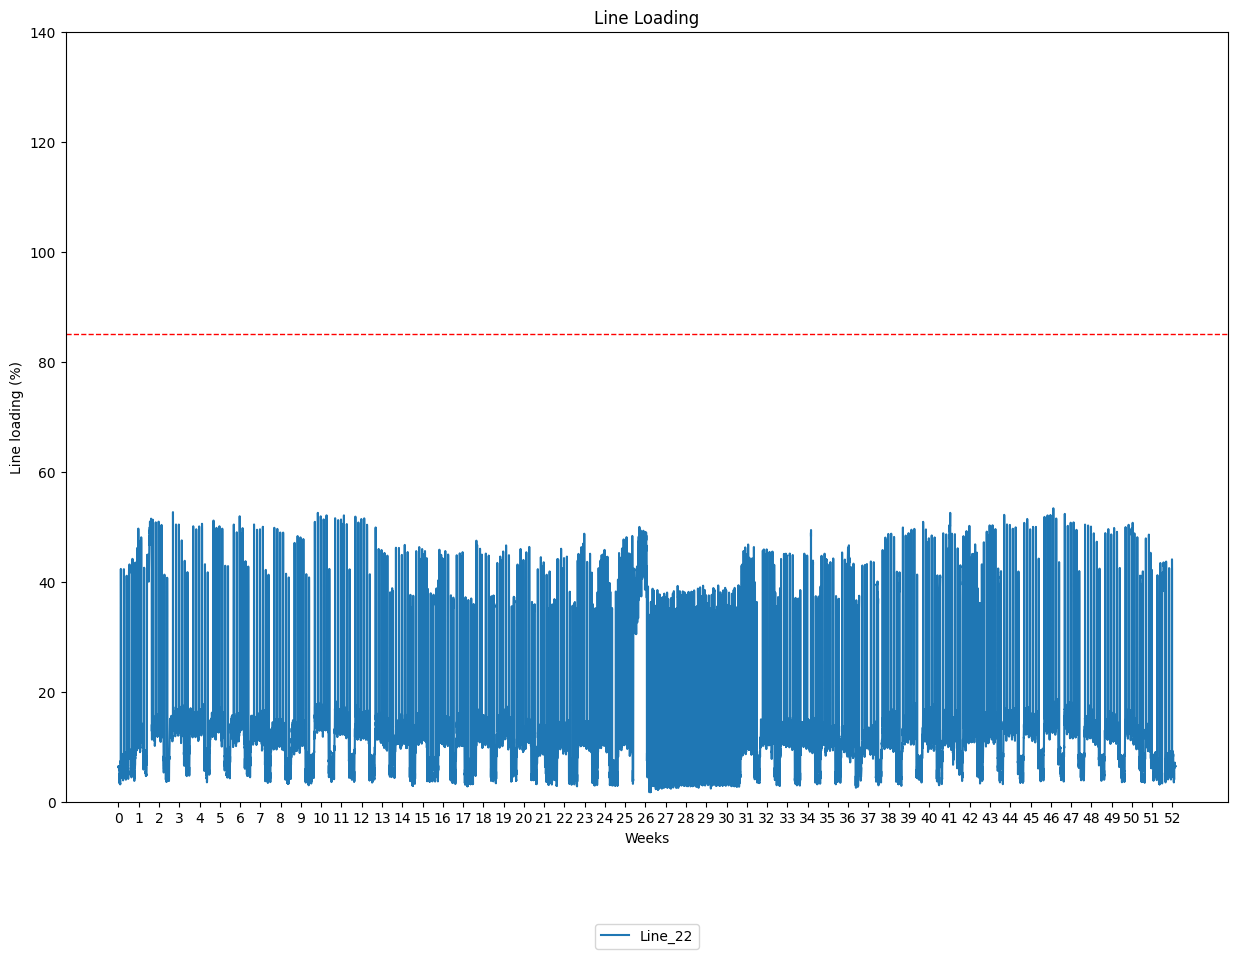

In [17]:
# Read the files
# Voltage magnitude
vm_pu_file = os.path.join(output_dir, "res_bus", "vm_pu.xlsx")
vm_pu = pd.read_excel(vm_pu_file, index_col=0)

# Line loading results
ll_file = os.path.join(output_dir, "res_line", "loading_percent.xlsx")
line_loading = pd.read_excel(ll_file, index_col=0)

# Trafo loading results
tl_file = os.path.join(output_dir, "res_trafo", "loading_percent.xlsx")
trafo_loading = pd.read_excel(tl_file, index_col=0)

# Helper function to convert timesteps to weeks
def timesteps_to_weeks(timesteps):
    return timesteps / 672

def week_axis_ticks(n_timesteps):
    ticks = list(range(0, n_timesteps, 672))
    return ticks, list(range(len(ticks)))


# Network Voltage magnitude (requested series)
column_indices_to_plot = [40, 44, 45, 46, 31]
legend_labels = ['Bus_55', 'LIH_mv', 'LIH_lv', 'LIH2_mv', 'Transformer LIH']

fig, ax = plt.subplots(figsize=(15, 10))
for i, column_index in enumerate(column_indices_to_plot):
    legend_label = legend_labels[i]
    vm_pu.iloc[:, column_index].plot(label=legend_label)

plt.axhline(y=0.9, color='red', linestyle='--', linewidth=1)
plt.axhline(y=1.1, color='red', linestyle='--', linewidth=1)
plt.xlabel("Weeks")
plt.ylabel("Voltage mag. [p.u.]")
plt.title("Voltage Magnitude")
plt.ylim(0.8, 1.2)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(column_indices_to_plot))
week_ticks, week_labels = week_axis_ticks(vm_pu.shape[0])
plt.xticks(ticks=week_ticks, labels=week_labels)
plt.grid(False)
plt.show()


# Line loading (requested series)
column_indices_to_plot = [22]
legend_labels = ['Line_22']

fig, ax = plt.subplots(figsize=(15, 10))
for i, column_index in enumerate(column_indices_to_plot):
    legend_label = legend_labels[i]
    line_loading.iloc[:, column_index].plot(label=legend_label)

plt.axhline(y=85, color='red', linestyle='--', linewidth=1)
plt.xlabel("Weeks")
plt.ylabel("Line loading (%)")
plt.title("Line Loading")
plt.ylim(0, 140)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(column_indices_to_plot))
week_ticks, week_labels = week_axis_ticks(line_loading.shape[0])
plt.xticks(ticks=week_ticks, labels=week_labels)
plt.grid(False)
plt.show()

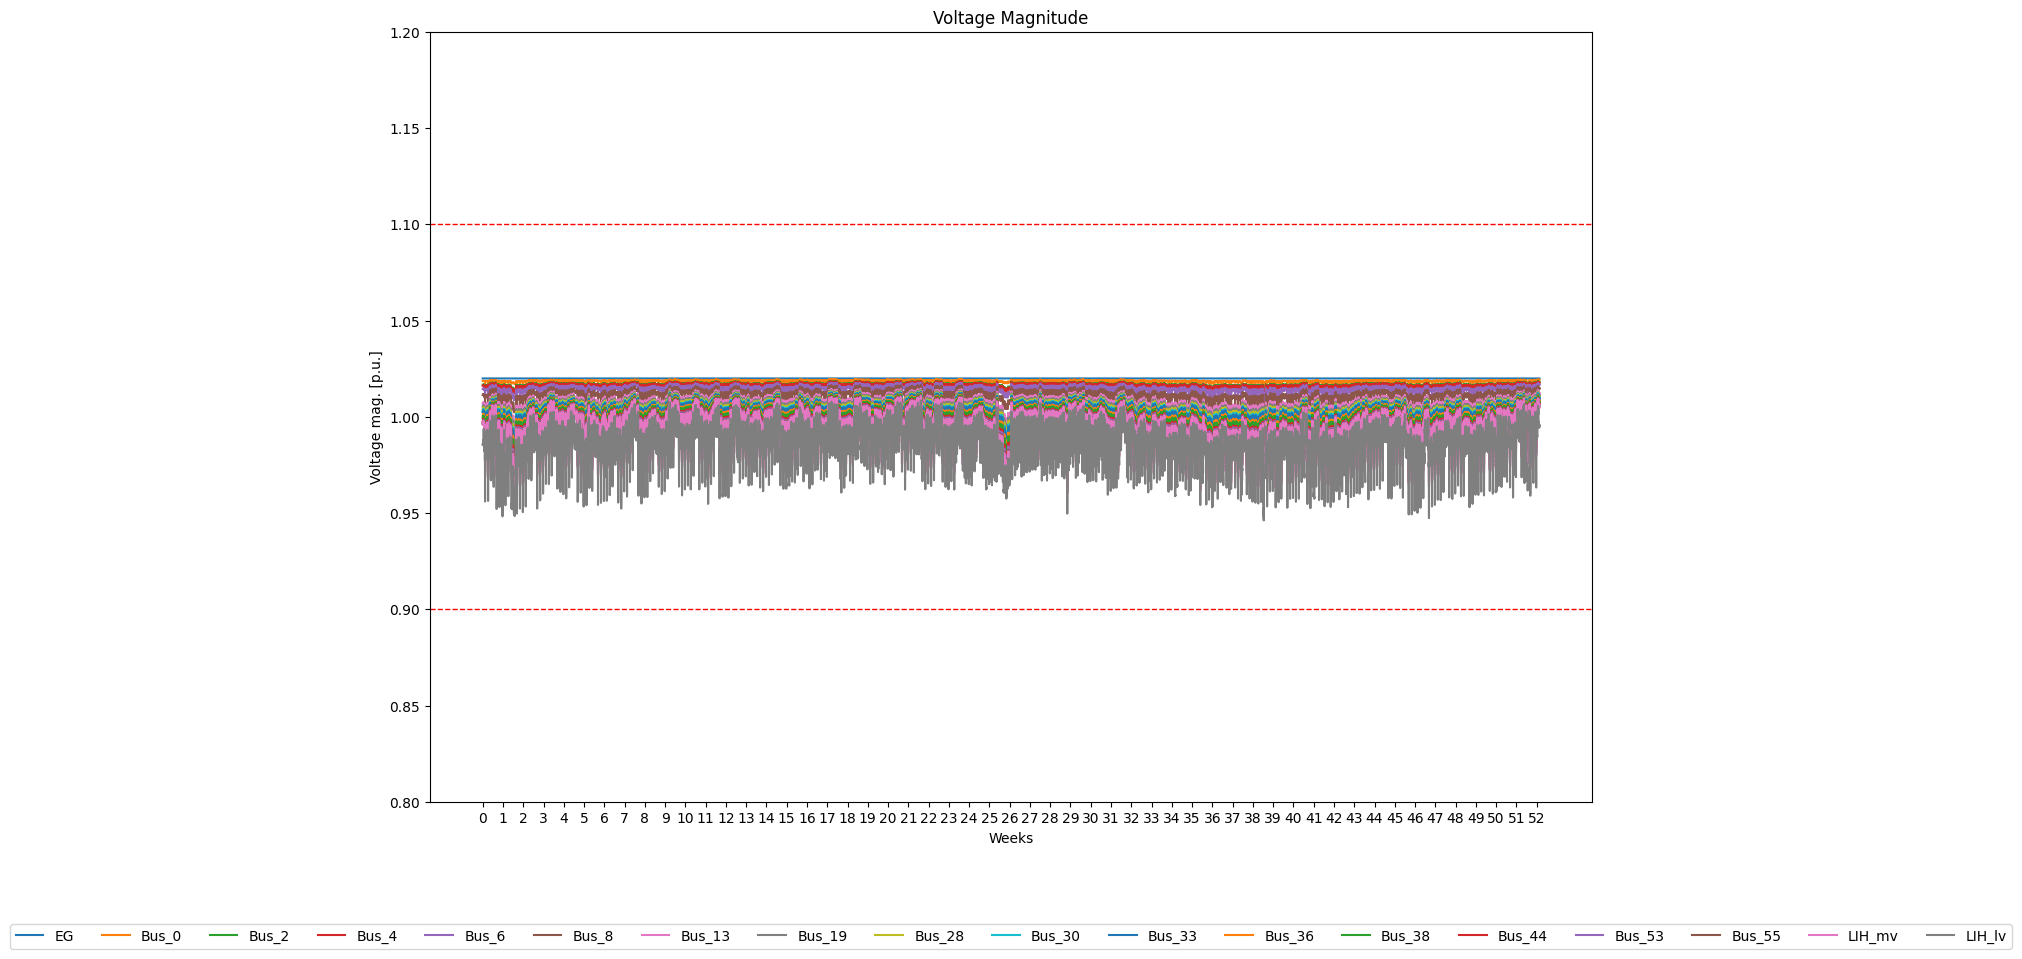

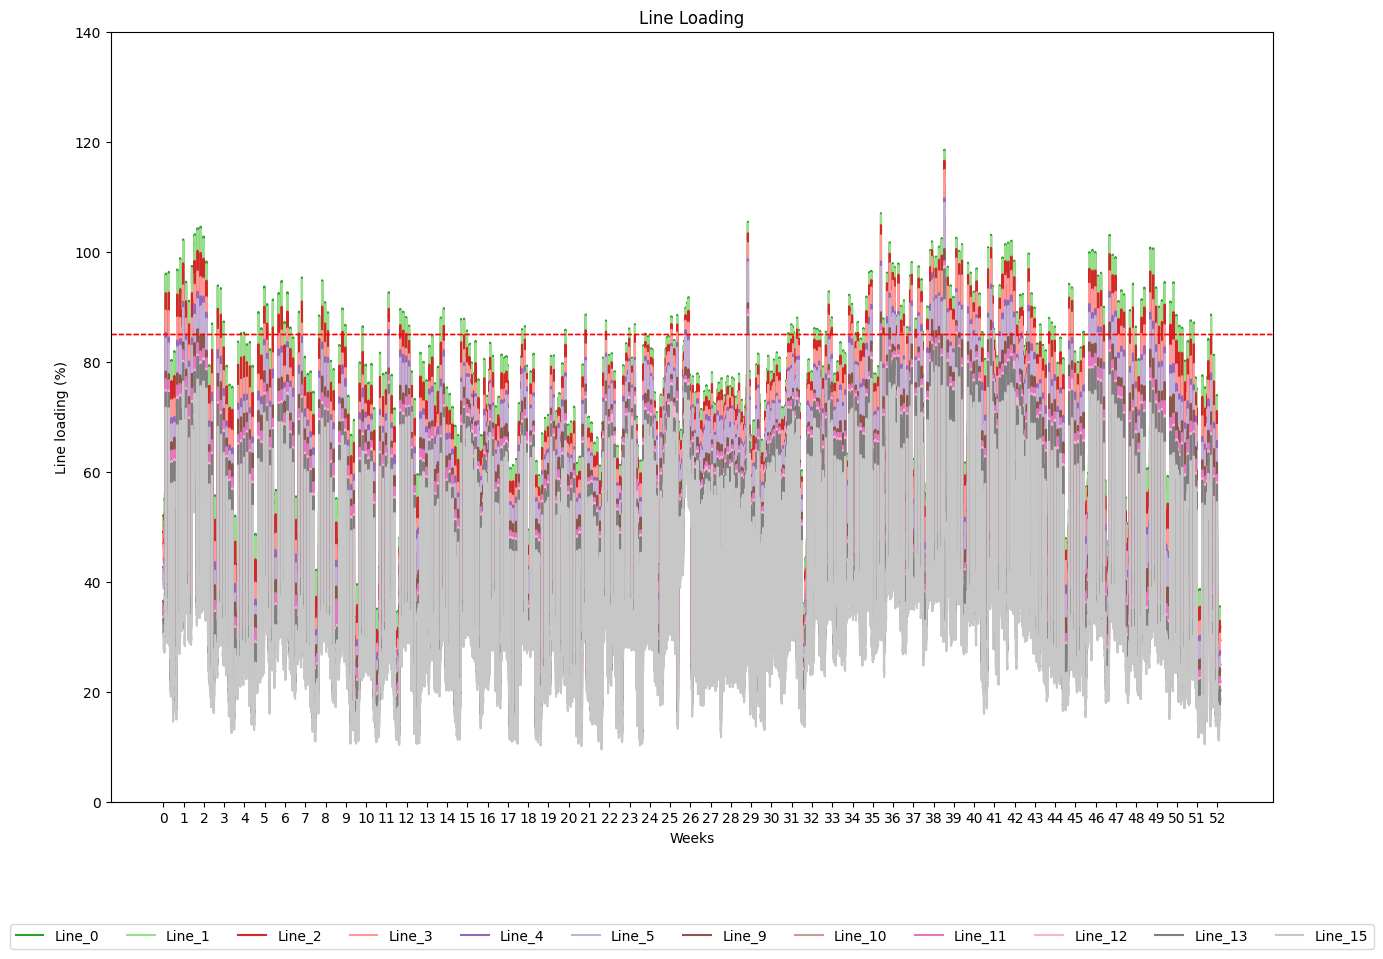

In [18]:
# Read the files
# Voltage magnitude
vm_pu_file = os.path.join(output_dir, "res_bus", "vm_pu.xlsx")
vm_pu = pd.read_excel(vm_pu_file, index_col=0)

# Line loading results
ll_file = os.path.join(output_dir, "res_line", "loading_percent.xlsx")
line_loading = pd.read_excel(ll_file, index_col=0)

# Trafo loading results
tl_file = os.path.join(output_dir, "res_trafo", "loading_percent.xlsx")
trafo_loading = pd.read_excel(tl_file, index_col=0)

# Helper function to convert timesteps to weeks
def timesteps_to_weeks(timesteps):
    return timesteps / 672

def week_axis_ticks(n_timesteps):
    ticks = list(range(0, n_timesteps, 672))
    return ticks, list(range(len(ticks)))

# Network Voltage magnitude
column_indices_to_plot = [0, 1, 2, 4, 6, 8, 10, 12, 18, 20, 21, 23, 25, 29, 38, 40, 44, 45]
legend_labels = ["EG", "Bus_0", "Bus_2", "Bus_4", "Bus_6", "Bus_8", "Bus_13", 
                "Bus_19", "Bus_28", "Bus_30", 
                 "Bus_33", "Bus_36", "Bus_38", "Bus_44", "Bus_53", "Bus_55", "LIH_mv", "LIH_lv"]
fig, ax = plt.subplots(figsize=(15, 10))
for i, column_index in enumerate(column_indices_to_plot):
    legend_label = legend_labels[i]
    vm_pu.iloc[:, column_index].plot(label=legend_label)
plt.axhline(y=0.9, color='red', linestyle='--', linewidth=1)
plt.axhline(y=1.1, color='red', linestyle='--', linewidth=1)
plt.xlabel("Weeks")
plt.ylabel("Voltage mag. [p.u.]")
plt.title("Voltage Magnitude")
plt.ylim(0.8, 1.2)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(column_indices_to_plot))
week_ticks, week_labels = week_axis_ticks(vm_pu.shape[0])
plt.xticks(ticks=week_ticks, labels=week_labels)
plt.grid(False)  # Remove gridlines
plt.show()

# Line loading (requested series)
column_indices_to_plot = [0, 1, 2, 3, 4, 5, 9, 10, 11, 12, 13, 15]
legend_labels = ['Line_0', 'Line_1', 'Line_2', 'Line_3', 'Line_4', 'Line_5',
                 'Line_9', 'Line_10', 'Line_11', 'Line_12', 'Line_13', 'Line_15']
# 12 distinct colors; skip tab10 indices 0–3 (used by the second plot)
plot_colors = [plt.cm.tab20(i) for i in range(4, 4 + len(column_indices_to_plot))]
fig, ax = plt.subplots(figsize=(15, 10))
for i, column_index in enumerate(column_indices_to_plot):
    line_loading.iloc[:, column_index].plot(
        label=legend_labels[i],
        color=plot_colors[i],
        ax=ax,
    )
plt.axhline(y=85, color='red', linestyle='--', linewidth=1)
plt.axhline(y=85, color='red', linestyle='--', linewidth=1)
plt.xlabel("Weeks")
plt.ylabel("Line loading (%)")
plt.title("Line Loading")
plt.ylim(0, 140)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(column_indices_to_plot))
week_ticks, week_labels = week_axis_ticks(line_loading.shape[0])
plt.xticks(ticks=week_ticks, labels=week_labels)
plt.grid(False)  # Remove gridlines
plt.show()

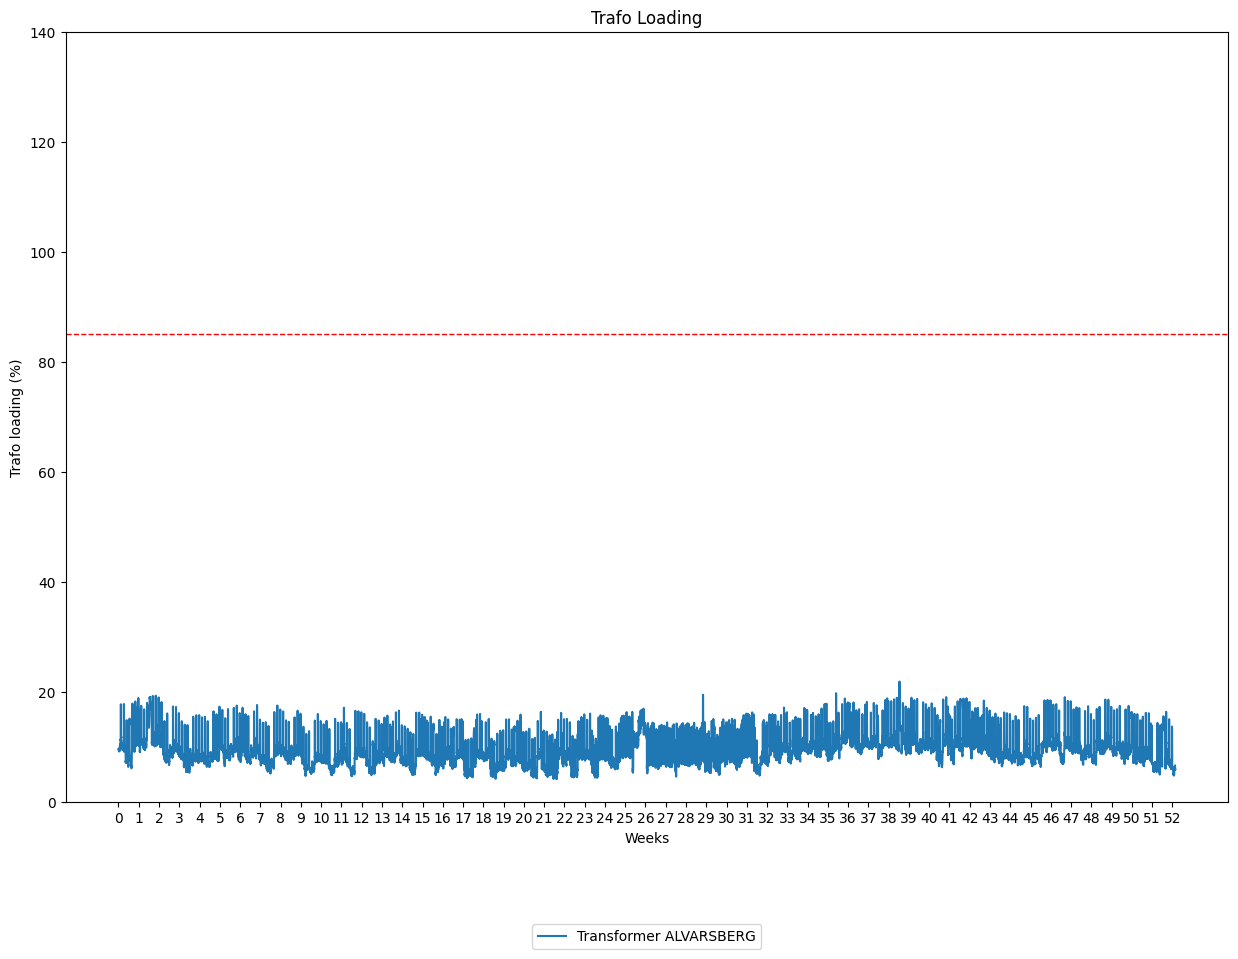

In [19]:
# Read the files

# Trafo loading results
tl_file = os.path.join(output_dir, "res_trafo", "loading_percent.xlsx")
trafo_loading = pd.read_excel(tl_file, index_col=0)

# Helper function to convert timesteps to weeks
def timesteps_to_weeks(timesteps):
    return timesteps / 672

def week_axis_ticks(n_timesteps):
    ticks = list(range(0, n_timesteps, 672))
    return ticks, list(range(len(ticks)))

# Trafo loading (Transformer ALVARSBERG)
columns_to_plot = [0]   # int
legend_labels = ['Transformer ALVARSBERG']

fig, ax = plt.subplots(figsize=(15, 10))
for i, col_name in enumerate(columns_to_plot):
    trafo_loading[col_name].plot(label=legend_labels[i])

plt.axhline(y=85, color='red', linestyle='--', linewidth=1)
plt.xlabel("Weeks")
plt.ylabel("Trafo loading (%)")
plt.title("Trafo Loading")
plt.ylim(0, 140)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(columns_to_plot))
week_ticks, week_labels = week_axis_ticks(trafo_loading.shape[0])
plt.xticks(ticks=week_ticks, labels=week_labels)
plt.grid(False)
plt.show()

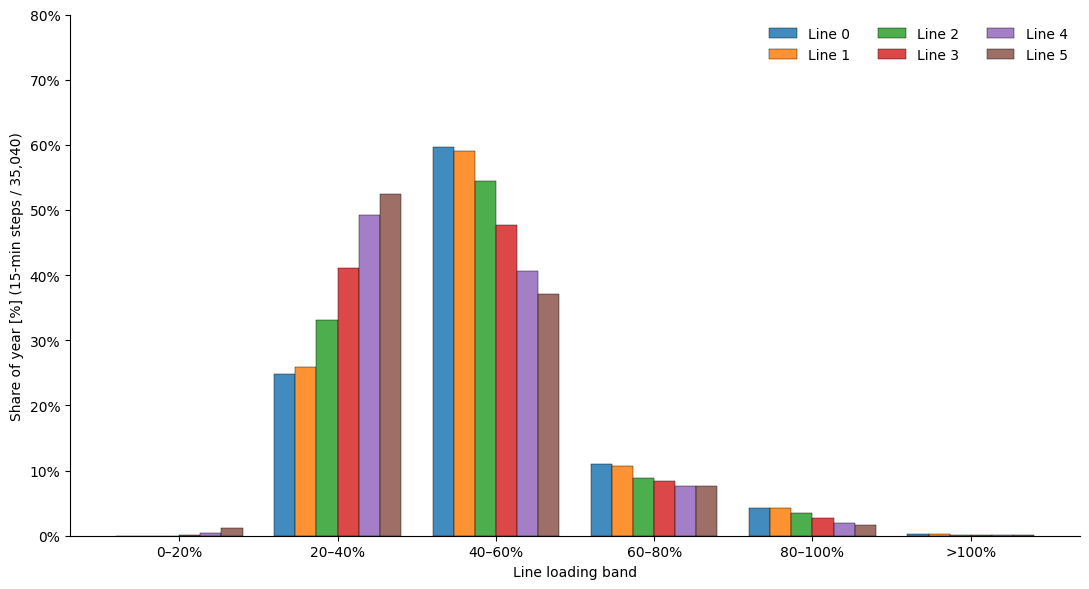

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --- inputs ---
ll_file = os.path.join(output_dir, "res_line", "loading_percent.xlsx")
line_loading = pd.read_excel(ll_file, index_col=0)

line_indices = [0, 1, 2, 3, 4, 5]
N_YEAR_15MIN = 35040  # yearly 15-min slots (your convention)

def counts_per_loading_band(s):
    """Counts timesteps with loading in each band (vectorized)."""
    x = s.dropna().to_numpy(dtype=float)
    return np.array(
        [
            np.sum((x >= 0) & (x < 20)),
            np.sum((x >= 20) & (x < 40)),
            np.sum((x >= 40) & (x < 60)),
            np.sum((x >= 60) & (x < 80)),
            np.sum((x >= 80) & (x <= 100)),
            np.sum(x > 100),
        ],
        dtype=float,
    )

def fraction_of_year_percent(counts, n_year=N_YEAR_15MIN):
    """Share of the 35,040 yearly 15-min steps [%]."""
    return counts / n_year * 100.0

band_labels = [
    "0–20%",
    "20–40%",
    "40–60%",
    "60–80%",
    "80–100%",
    ">100%",
]

# counts[line, band]
counts_mat = np.stack(
    [counts_per_loading_band(line_loading.iloc[:, idx]) for idx in line_indices],
    axis=0,
)
y_mat = np.stack([fraction_of_year_percent(counts_mat[i]) for i in range(len(line_indices))], axis=0)

# --- plot: grouped bars ---
n_bands = len(band_labels)
n_lines = len(line_indices)
x = np.arange(n_bands)
bar_w = 0.8 / n_lines

fig, ax = plt.subplots(figsize=(11, 6))
cmap = plt.cm.tab10.colors

for k, idx in enumerate(line_indices):
    offset = (k - (n_lines - 1) / 2) * bar_w
    ax.bar(
        x + offset,
        y_mat[k],
        width=bar_w,
        color=cmap[k % 10],
        edgecolor="black",
        linewidth=0.35,
        alpha=0.85,
        label=f"Line {idx}",
    )

ax.set_xticks(x)
ax.set_xticklabels(band_labels)
ax.set_xlabel("Line loading band")
ax.set_ylabel("Share of year [%] (15-min steps / 35,040)")

ax.set_ylim(0, 80)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}%"))

ax.legend(ncol=3, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

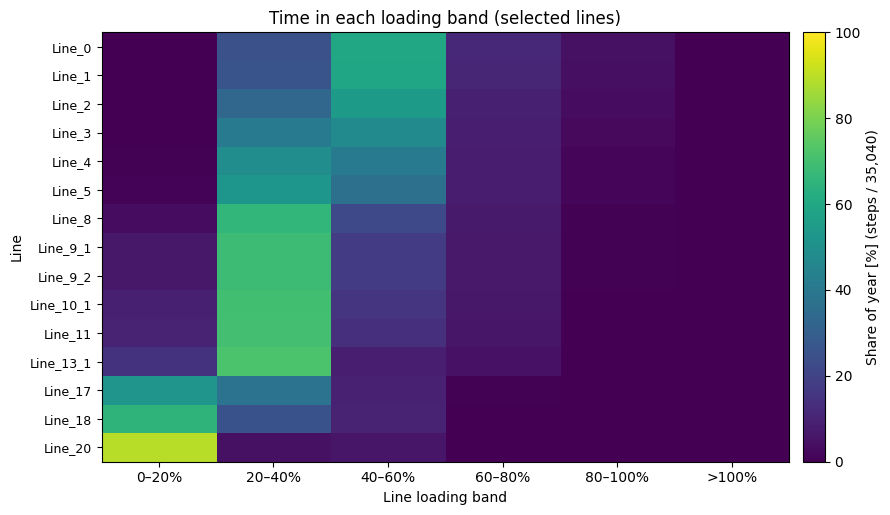

In [21]:
column_indices_to_plot = [0, 1, 2, 3, 4, 5, 9, 10, 11, 12, 13, 15, 20, 21, 22]
legend_labels = [
    "Line_0", "Line_1", "Line_2", "Line_3", "Line_4", "Line_5",
    "Line_8", "Line_9_1", "Line_9_2", "Line_10_1", "Line_11", "Line_13_1",
    "Line_17", "Line_18", "Line_20",
]

assert len(column_indices_to_plot) == len(legend_labels)

counts_mat = np.stack(
    [counts_per_loading_band(line_loading.iloc[:, idx]) for idx in column_indices_to_plot],
    axis=0,
)
Z = np.stack(
    [fraction_of_year_percent(counts_mat[i]) for i in range(len(column_indices_to_plot))],
    axis=0,
)

n_lines, n_bands = Z.shape
fig_h = min(24, max(5, 0.35 * n_lines))
fig, ax = plt.subplots(figsize=(9, fig_h))

im = ax.imshow(Z, aspect="auto", cmap="viridis", vmin=0, vmax=100, interpolation="nearest")

ax.set_xticks(np.arange(n_bands))
ax.set_xticklabels(band_labels)
ax.set_yticks(np.arange(n_lines))
ax.set_yticklabels(legend_labels, fontsize=9)
ax.set_xlabel("Line loading band")
ax.set_ylabel("Line")

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Share of year [%] (steps / 35,040)")

ax.set_title("Time in each loading band (selected lines)")
plt.tight_layout()
plt.show()

In [22]:
import numpy as np
import pandas as pd

column_indices_to_plot = [0, 1, 2, 3, 4, 5, 9, 10, 11, 12, 13, 15, 20, 21, 22]
legend_labels = [
    "Line_0", "Line_1", "Line_2", "Line_3", "Line_4", "Line_5",
    "Line_9", "Line_10", "Line_11", "Line_12", "Line_13", "Line_15",
    "Line_20", "Line_21", "Line_22",
]

assert len(column_indices_to_plot) == len(legend_labels)


def max_consecutive_true(mask: np.ndarray) -> int:
    """Longest run of True values (0 if none)."""
    m = mask.astype(np.int8)
    if m.sum() == 0:
        return 0
    padded = np.concatenate([[0], m, [0]])
    d = np.diff(padded)
    starts = np.where(d == 1)[0]
    ends = np.where(d == -1)[0]
    return int((ends - starts).max())

rows = []
for idx, name in zip(column_indices_to_plot, legend_labels):
    s = line_loading.iloc[:, idx].to_numpy(dtype=float)
    s = s[~np.isnan(s)]

    m80 = s >= 80.0
    m100 = s > 100.0

    rows.append(
        {
            "line": name,
            "index": idx,
            "max_loading_pct": float(np.max(s)),  # maximum loading % for this line
            "n_steps_ge_80": int(m80.sum()),
            "n_steps_gt_100": int(m100.sum()),
            "max_consecutive_ge_80": max_consecutive_true(m80),
            "max_consecutive_gt_100": max_consecutive_true(m100),
        }
    )

summary = pd.DataFrame(rows)

# Optional: express streaks as hours / days (15 min each)
summary["max_consecutive_ge_80_hours"] = summary["max_consecutive_ge_80"] * 0.25
summary["max_consecutive_gt_100_hours"] = summary["max_consecutive_gt_100"] * 0.25

out_path = "dumb/outputs"
os.makedirs(out_path, exist_ok=True)
out_path = os.path.join(out_path, "line_overloading_summary.xlsx")
summary.to_excel(out_path, index=False, sheet_name="line_overloading_summary", engine="openpyxl")

summary

,line,index,max_loading_pct,n_steps_ge_80,n_steps_gt_100,max_consecutive_ge_80,max_consecutive_gt_100,max_consecutive_ge_80_hours,max_consecutive_gt_100_hours
0,Line_0,0,118.596287,1601,90,83,19,20.75,4.75
1,Line_1,1,118.267538,1551,83,82,19,20.50,4.75
2,Line_2,2,116.592437,1229,33,77,19,19.25,4.75
3,Line_3,3,114.913992,964,24,75,19,18.75,4.75
4,Line_4,4,109.739364,702,19,75,19,18.75,4.75
5,Line_5,5,108.966964,594,19,74,19,18.50,4.75
6,Line_9,9,100.569479,253,1,19,1,4.75,0.25
7,Line_10,10,98.319452,144,0,19,0,4.75,0.00
8,Line_11,11,98.319467,144,0,19,0,4.75,0.00
9,Line_12,12,97.444359,91,0,19,0,4.75,0.00


In [23]:
subset = line_loading.iloc[:, column_indices_to_plot]
n_timesteps_any_line_gt_100 = int(subset.gt(100.0).any(axis=1).sum())
n_timesteps_any_line_gt_80 = int(subset.gt(80.0).any(axis=1).sum())

print(f"Total timesteps with any line > 100%: {n_timesteps_any_line_gt_100}")
print(f"Total timesteps with any line > 80%: {n_timesteps_any_line_gt_80}")

Total timesteps with any line > 100%: 90
Total timesteps with any line > 80%: 1601


In [24]:
import numpy as np
import pandas as pd

LINE_IDX = 0


def longest_true_run_interval(mask: np.ndarray):
    """
    First longest run of True in `mask`.
    Returns (start_i, end_i) inclusive, or None if no True.
    """
    m = mask.astype(np.int8)
    if m.sum() == 0:
        return None
    padded = np.concatenate([[0], m, [0]])
    d = np.diff(padded)
    starts = np.where(d == 1)[0]
    ends = np.where(d == -1)[0] - 1
    lengths = ends - starts + 1
    j = int(np.argmax(lengths))
    return int(starts[j]), int(ends[j])


# --- line 0 loading ---
s = line_loading.iloc[:, LINE_IDX].to_numpy(dtype=float)
mask = s > 100.0

run = longest_true_run_interval(mask)
if run is None:
    print("Line 0: no timesteps with loading > 100%.")
else:
    i0, i1 = run
    n_steps = i1 - i0 + 1
    max_consecutive_gt_100_hours = n_steps * 0.25  # 15 min per step

    if len(profilesA) != len(line_loading) or len(profilesR) != len(line_loading):
        raise ValueError("profiles and line_loading row counts do not match.")

    # Timesteps in that interval (positional rows i0..i1)
    if isinstance(line_loading.index, pd.RangeIndex) and line_loading.index.start == 0:
        timesteps = np.arange(i0, i1 + 1)
    else:
        timesteps = line_loading.index[i0 : i1 + 1].to_numpy()

    loads_p = profilesA.iloc[i0 : i1 + 1].copy()
    loads_q = profilesR.iloc[i0 : i1 + 1].copy()
    loads_p.insert(0, "timestep", timesteps)
    loads_q.insert(0, "timestep", timesteps)

    meta = pd.Series(
        {
            "line_index": LINE_IDX,
            "run_start_row": i0,
            "run_end_row": i1,
            "n_15min_steps": n_steps,
            "max_consecutive_gt_100_hours": max_consecutive_gt_100_hours,
        }
    )

    display(meta.to_frame("value"))
    display(loads_p)
    display(loads_q)

,value
line_index,0.00
run_start_row,25884.00
run_end_row,25902.00
n_15min_steps,19.00
max_consecutive_gt_100_hours,4.75


,timestep,Bus 3,Bus 5,Bus 7 URA,Bus 9,Bus 14 LAX,Bus 20 KBV,Bus 24,Bus 26 KRVA,Bus 29 BVH,...,Bus 45,Bus 47,Bus 49,Bus 52,Bus 54,Bus 56,Bus 58 JUN,Bus LIH OPS,Bus LIH,Bus LIH2
25884,25884,0.002385,0.04190,0.04190,0.18672,0.021120,0.080850,0.26091,0.347616,0.119232,...,0.18672,0.52182,0.18672,0.78273,0.26091,0.78273,2.526114,1.4940,0.064064,0.058302
25885,25885,0.002385,0.04190,0.04190,0.18672,0.021120,0.080850,0.26091,0.347616,0.119232,...,0.18672,0.52182,0.18672,0.78273,0.26091,0.78273,2.526114,1.4940,0.081325,0.056940
25886,25886,0.002385,0.04190,0.04190,0.18672,0.021120,0.080850,0.26091,0.347616,0.119232,...,0.18672,0.52182,0.18672,0.78273,0.26091,0.78273,2.526114,1.4940,0.081325,0.064031
25887,25887,0.002385,0.04190,0.04190,0.18672,0.021120,0.080850,0.26091,0.347616,0.119232,...,0.18672,0.52182,0.18672,0.78273,0.26091,0.78273,2.526114,1.4940,0.081325,0.060727
25888,25888,0.002079,0.04574,0.04574,0.20020,0.022074,0.083925,0.26631,0.352432,0.092923,...,0.20020,0.53262,0.20020,0.79893,0.26631,0.79893,2.511468,1.4940,0.044922,0.067829
25889,25889,0.002079,0.04574,0.04574,0.20020,0.022074,0.083925,0.26631,0.352432,0.092923,...,0.20020,0.53262,0.20020,0.79893,0.26631,0.79893,2.511468,1.4940,0.042650,0.060131
25890,25890,0.002079,0.04574,0.04574,0.20020,0.022074,0.083925,0.26631,0.352432,0.092923,...,0.20020,0.53262,0.20020,0.79893,0.26631,0.79893,2.511468,1.4940,0.043004,0.061345
25891,25891,0.002079,0.04574,0.04574,0.20020,0.022074,0.083925,0.26631,0.352432,0.092923,...,0.20020,0.53262,0.20020,0.79893,0.26631,0.79893,2.511468,1.4940,0.053099,0.062695
25892,25892,0.001651,0.06476,0.06476,0.21030,0.021042,0.085350,0.25359,0.285160,0.083729,...,0.21030,0.50718,0.21030,0.76077,0.25359,0.76077,2.511864,1.4940,0.046789,0.093212
25893,25893,0.001651,0.06476,0.06476,0.21030,0.021042,0.085350,0.25359,0.285160,0.083729,...,0.21030,0.50718,0.21030,0.76077,0.25359,0.76077,2.511864,1.4940,0.054865,0.089103


,timestep,Bus 3,Bus 5,Bus 7 URA,Bus 9,Bus 14 LAX,Bus 20- KBV,Bus 24,Bus 26 KRVA,Bus 29 BVH,...,Bus 45,Bus 47,Bus 49,Bus 52,Bus 54,Bus 56,Bus 58 JUN,Bus LIH OPS,Bus LIH,Bus LIH2
25884,25884,0.000784,0.00766,0.00766,0.061372,0.006942,0.009025,0.085757,0.114256,0.039190,...,0.061372,0.171514,0.061372,0.257271,0.085757,0.257271,0.830294,0.491054,0.021057,0.0
25885,25885,0.000784,0.00766,0.00766,0.061372,0.006942,0.009025,0.085757,0.114256,0.039190,...,0.061372,0.171514,0.061372,0.257271,0.085757,0.257271,0.830294,0.491054,0.026730,0.0
25886,25886,0.000784,0.00766,0.00766,0.061372,0.006942,0.009025,0.085757,0.114256,0.039190,...,0.061372,0.171514,0.061372,0.257271,0.085757,0.257271,0.830294,0.491054,0.026730,0.0
25887,25887,0.000784,0.00766,0.00766,0.061372,0.006942,0.009025,0.085757,0.114256,0.039190,...,0.061372,0.171514,0.061372,0.257271,0.085757,0.257271,0.830294,0.491054,0.026730,0.0
25888,25888,0.000683,0.00450,0.00450,0.065803,0.007255,0.005325,0.087532,0.115839,0.030542,...,0.065803,0.175064,0.065803,0.262596,0.087532,0.262596,0.825480,0.491054,0.014765,0.0
25889,25889,0.000683,0.00450,0.00450,0.065803,0.007255,0.005325,0.087532,0.115839,0.030542,...,0.065803,0.175064,0.065803,0.262596,0.087532,0.262596,0.825480,0.491054,0.014019,0.0
25890,25890,0.000683,0.00450,0.00450,0.065803,0.007255,0.005325,0.087532,0.115839,0.030542,...,0.065803,0.175064,0.065803,0.262596,0.087532,0.262596,0.825480,0.491054,0.014135,0.0
25891,25891,0.000683,0.00450,0.00450,0.065803,0.007255,0.005325,0.087532,0.115839,0.030542,...,0.065803,0.175064,0.065803,0.262596,0.087532,0.262596,0.825480,0.491054,0.017453,0.0
25892,25892,0.000543,0.00828,0.00828,0.069122,0.006916,0.004375,0.083351,0.093728,0.027520,...,0.069122,0.166702,0.069122,0.250053,0.083351,0.250053,0.825610,0.491054,0.015379,0.0
25893,25893,0.000543,0.00828,0.00828,0.069122,0.006916,0.004375,0.083351,0.093728,0.027520,...,0.069122,0.166702,0.069122,0.250053,0.083351,0.250053,0.825610,0.491054,0.018033,0.0


In [25]:
import os
import pandas as pd

# --- configuration ---
line_indices = [0, 1, 2, 3, 4, 5]
LOADING_THRESHOLD = 100.0  # use >= 100 % on loading_percent

ll_file = os.path.join(output_dir, "res_line", "loading_percent.xlsx")
line_loading = pd.read_excel(ll_file, index_col=0)

# --- align line results with profiles (same timestep order) ---
# If your Excel index is 0..35039 for both, this is enough:
if len(line_loading) != len(profilesA) or len(line_loading) != len(profilesR):
    raise ValueError(
        f"Row count mismatch: line_loading {len(line_loading)}, "
        f"profilesA {len(profilesA)}, profilesR {len(profilesR)}"
    )

# Timestep label for output: use dataframe index if you trust it, else position
if line_loading.index.equals(pd.RangeIndex(len(line_loading))):
    timestep_series = pd.Series(range(len(line_loading)), name="timestep")
else:
    timestep_series = pd.Series(line_loading.index, name="timestep")

# --- find (timestep, line) where loading >= threshold ---
events = []
for lid in line_indices:
    col = line_loading.iloc[:, lid]
    mask = col >= LOADING_THRESHOLD
    for i in mask.to_numpy().nonzero()[0]:
        events.append(
            {
                "timestep": timestep_series.iloc[i],
                "row_position": int(i),
                "line_index": int(lid),
                "loading_percent": float(col.iloc[i]),
            }
        )

events_df = pd.DataFrame(events).sort_values(["timestep", "line_index"]).reset_index(drop=True)

# --- for each event, attach full-network load P and Q from profiles ---

def pq_snapshot(row_pos: int) -> pd.Series:
    """One row of all loads: P columns prefixed P|, Q prefixed Q|."""
    p = profilesA.iloc[row_pos].add_prefix("P_MW__")
    q = profilesR.iloc[row_pos].add_prefix("Q_MVAr__")
    return pd.concat([p, q])

snap_rows = []
for _, ev in events_df.iterrows():
    r = int(ev["row_position"])
    snap = pq_snapshot(r)
    snap_rows.append(pd.concat([ev.drop(labels=["row_position"]), snap]))

result_wide = pd.DataFrame(snap_rows)

# Optional: pretty column names → load index + bus name (if net is in scope)
try:
    load_ix = net.load.index[net.load.in_service].tolist()
    prof_cols = list(profilesA.columns)
    rename_p = {}
    rename_q = {}
    for k, li in enumerate(load_ix):
        if k >= len(prof_cols):
            break
        c = prof_cols[k]
        bus = int(net.load.at[li, "bus"])
        bname = net.bus.at[bus, "name"]
        tag = f"load{li}_bus_{bname}"
        rename_p[f"P_MW__{c}"] = f"P_MW__{tag}"
        rename_q[f"Q_MVAr__{c}"] = f"Q_MVAr__{tag}"
    result_wide = result_wide.rename(columns={**rename_p, **rename_q})
except NameError:
    pass  # no net → keep original profile column names

result_wide.describe()

,timestep,line_index,loading_percent,P_MW__load0_bus_Bus_3,P_MW__load1_bus_Bus_5,P_MW__load2_bus_Bus_7,P_MW__load3_bus_Bus_9,P_MW__load4_bus_Bus_14,P_MW__load5_bus_Bus_20,P_MW__load6_bus_Bus_24,...,Q_MVAr__load14_bus_Bus_47,Q_MVAr__load15_bus_Bus_49,Q_MVAr__load17_bus_Bus_54,Q_MVAr__load18_bus_Bus_56,Q_MVAr__load20_bus_LIH_mv,Q_MVAr__load21_bus_LIH_lv,Q_MVAr__load22_bus_LIH2_lv,Q_MVAr__Bus LIH OPS,Q_MVAr__Bus LIH,Q_MVAr__Bus LIH2
count,268.000000,268.000000,268.000000,268.000000,268.00000,268.00000,268.000000,268.000000,268.000000,268.000000,...,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000
mean,21706.440299,1.462687,106.105536,0.002458,0.09232,0.09232,0.174780,0.030544,0.085096,0.192748,...,0.057447,0.126706,0.057447,0.190059,0.063353,0.190059,0.777329,0.482966,0.045489,0.009106
std,9584.004756,1.544141,5.775839,0.001311,0.04597,0.04597,0.038776,0.015889,0.020780,0.065230,...,0.012745,0.042880,0.012745,0.064320,0.021440,0.064320,0.145526,0.022548,0.021151,0.013245
min,657.000000,0.000000,100.009485,0.000898,0.04190,0.04190,0.098400,0.011628,0.025725,0.083490,...,0.032343,0.054884,0.032343,0.082326,0.027442,0.082326,0.273162,0.382194,0.014019,0.000000
25%,23792.000000,0.000000,101.354773,0.001514,0.06476,0.06476,0.144260,0.021042,0.080850,0.123720,...,0.047416,0.081330,0.047416,0.121995,0.040665,0.121995,0.794096,0.490397,0.026730,0.000000
50%,25889.500000,1.000000,103.175597,0.002079,0.07564,0.07564,0.186720,0.022500,0.085350,0.235500,...,0.061372,0.154810,0.061372,0.232216,0.077405,0.232216,0.825480,0.491054,0.043233,0.000000
75%,25901.000000,2.000000,112.126407,0.003147,0.11220,0.11220,0.206660,0.039792,0.095181,0.255420,...,0.067926,0.167905,0.067926,0.251858,0.083953,0.251858,0.831246,0.491054,0.059413,0.016279
max,32819.000000,5.000000,118.596287,0.007476,0.19032,0.19032,0.227700,0.069912,0.125925,0.266310,...,0.074841,0.175064,0.074841,0.262596,0.087532,0.262596,0.891681,0.491054,0.088640,0.044249
